<a href="https://colab.research.google.com/github/estebancardonad/Trabajos_Python_xd/blob/main/Sesion_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
import warnings

In [13]:
!pip install yfinance


In [14]:
import yfinance as yf
tickers="TTWO"
data=yf.download(tickers=tickers,period="1y", interval="1d",
                 auto_adjust=True, prepost=True)["Close"].dropna()

[*********************100%***********************]  1 of 1 completed


In [15]:
len(data)

251

In [16]:
import numpy as np

In [17]:
data["index"]=np.arange(1,len(data)+1)

In [18]:
data.head()

Ticker,TTWO,index
Date,,
2024-11-26,187.850006,1
2024-11-27,185.559998,2
2024-11-29,188.380005,3
2024-12-02,187.949997,4
2024-12-03,188.059998,5


In [19]:
import matplotlib.pyplot as plt

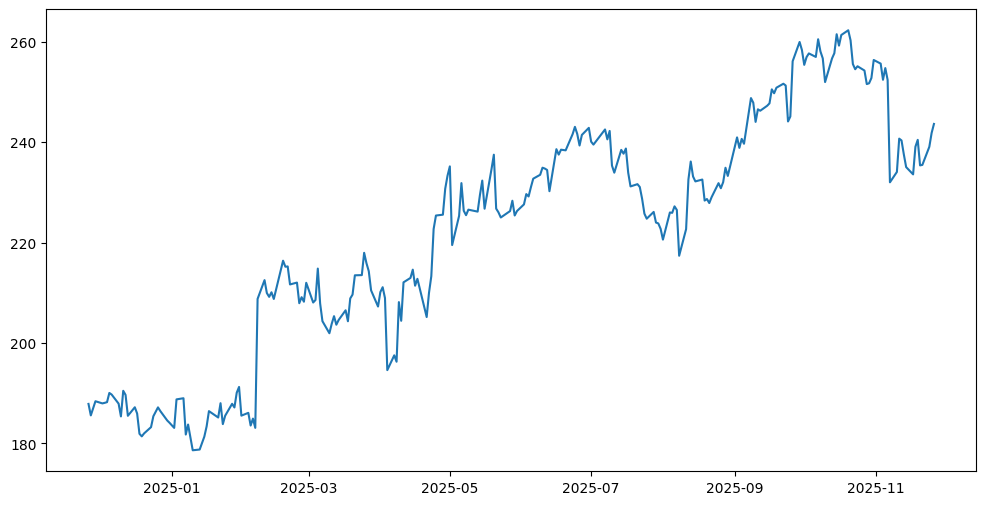

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(data['TTWO'])

Aumento por el trailer de GTA 6 a inicio de año y caida por el retraso del mismo askljdhasjk

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import scipy.stats as stats

X=data["index"].values.reshape(-1, 1)
y=data["TTWO"].values
modelorl= LinearRegression()
modelorl.fit(X, y)
y_pred = modelorl.predict(X)

#Parametros del modelo
pendiente = modelorl.coef_[0]
intercepto = modelorl.intercept_

# Estadisticos del modelo
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

    # 6. Estadísticas adicionales
n = len(y)
correlacion = np.corrcoef(X.flatten(), y)[0, 1]

print("="*50)
print("REGRESIÓN LINEAL SIMPLE")
print("="*50)
print(f"Número de observaciones: {n}")
print("\nECUACIÓN DE REGRESIÓN:")
print(f"Y = {intercepto:.4f} + {pendiente:.4f} * X")
print(f"\nMÉTRICAS DEL MODELO:")
print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"Correlación (r): {correlacion:.4f}")
print(f"MSE (Error Cuadrático Medio): {mse:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.4f}")

REGRESIÓN LINEAL SIMPLE
Número de observaciones: 251

ECUACIÓN DE REGRESIÓN:
Y = 185.6263 + 0.2921 * X

MÉTRICAS DEL MODELO:
R² (Coeficiente de determinación): 0.8319
Correlación (r): 0.9121
MSE (Error Cuadrático Medio): 90.5213
RMSE (Raíz del Error Cuadrático Medio): 9.5143


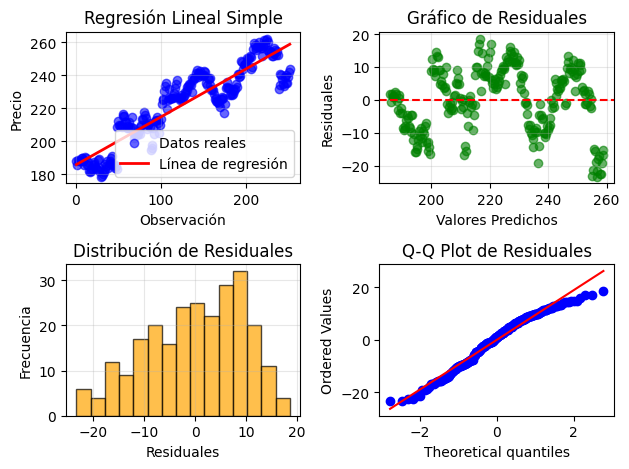

In [23]:
# Gráfico de dispersión con línea de regresión
plt.subplot(2, 2, 1)
plt.scatter(X, y, alpha=0.6, color='blue', label='Datos reales')
plt.plot(X, y_pred, color='red', linewidth=2, label='Línea de regresión')
plt.title('Regresión Lineal Simple')
plt.xlabel('Observación')
plt.ylabel('Precio')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico de residuales
residuos = y - y_pred
plt.subplot(2, 2, 2)
plt.scatter(y_pred, residuos, alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuales')
plt.title('Gráfico de Residuales')
plt.grid(True, alpha=0.3)

# Histograma de residuales
plt.subplot(2, 2, 3)
plt.hist(residuos, bins=15, alpha=0.7, color='orange', edgecolor='black')
plt.xlabel('Residuales')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuales')
plt.grid(True, alpha=0.3)

# Q-Q plot para normalidad
plt.subplot(2, 2, 4)
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuales')

plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Calcular media móvil de 3 periodos
data['TTWO_MA3'] = data['TTWO'].rolling(window=3).mean().shift(1).dropna()

# Preparar datos (eliminar NaN)
datos_ma3 = data.dropna(subset=['TTWO_MA3'])

# The 'predictions' are now the moving average values themselves
y_pred_ma = datos_ma3['TTWO_MA3'].values

# Align the original 'EC' values with the length of the moving average data
y_original_aligned = datos_ma3['TTWO'].values

# Parámetros y métricas
# In this direct moving average approach, there are no 'pendiente' or 'intercepto' from a regression model
# However, we can still calculate R2 and RMSE by comparing the MA to the original data

r2 = r2_score(y_original_aligned, y_pred_ma)
rmse = np.sqrt(mean_squared_error(y_original_aligned, y_pred_ma))

print("="*50)
print("ESTRATEGIA PREDICTORIA: MEDIA MÓVIL (3 PERIODOS)")
print("="*50)
print(f"El pronóstico es directamente la Media Móvil de 3 períodos.")
print(f"\nMÉTRICAS DE RENDIMIENTO (vs. valores originales alineados):")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Observaciones: {len(y_original_aligned)}")

ESTRATEGIA PREDICTORIA: MEDIA MÓVIL (3 PERIODOS)
El pronóstico es directamente la Media Móvil de 3 períodos.

MÉTRICAS DE RENDIMIENTO (vs. valores originales alineados):
R²: 0.9563
RMSE: 4.8097
Observaciones: 248


In [25]:
data

Ticker,TTWO,index,TTWO_MA3
Date,,,
2024-11-26,187.850006,1,NaN
2024-11-27,185.559998,2,NaN
2024-11-29,188.380005,3,NaN
2024-12-02,187.949997,4,187.263336
2024-12-03,188.059998,5,187.296666
...,...,...,...
2025-11-20,235.369995,247,237.710002
2025-11-21,235.470001,248,238.306666
2025-11-24,239.070007,249,237.100001


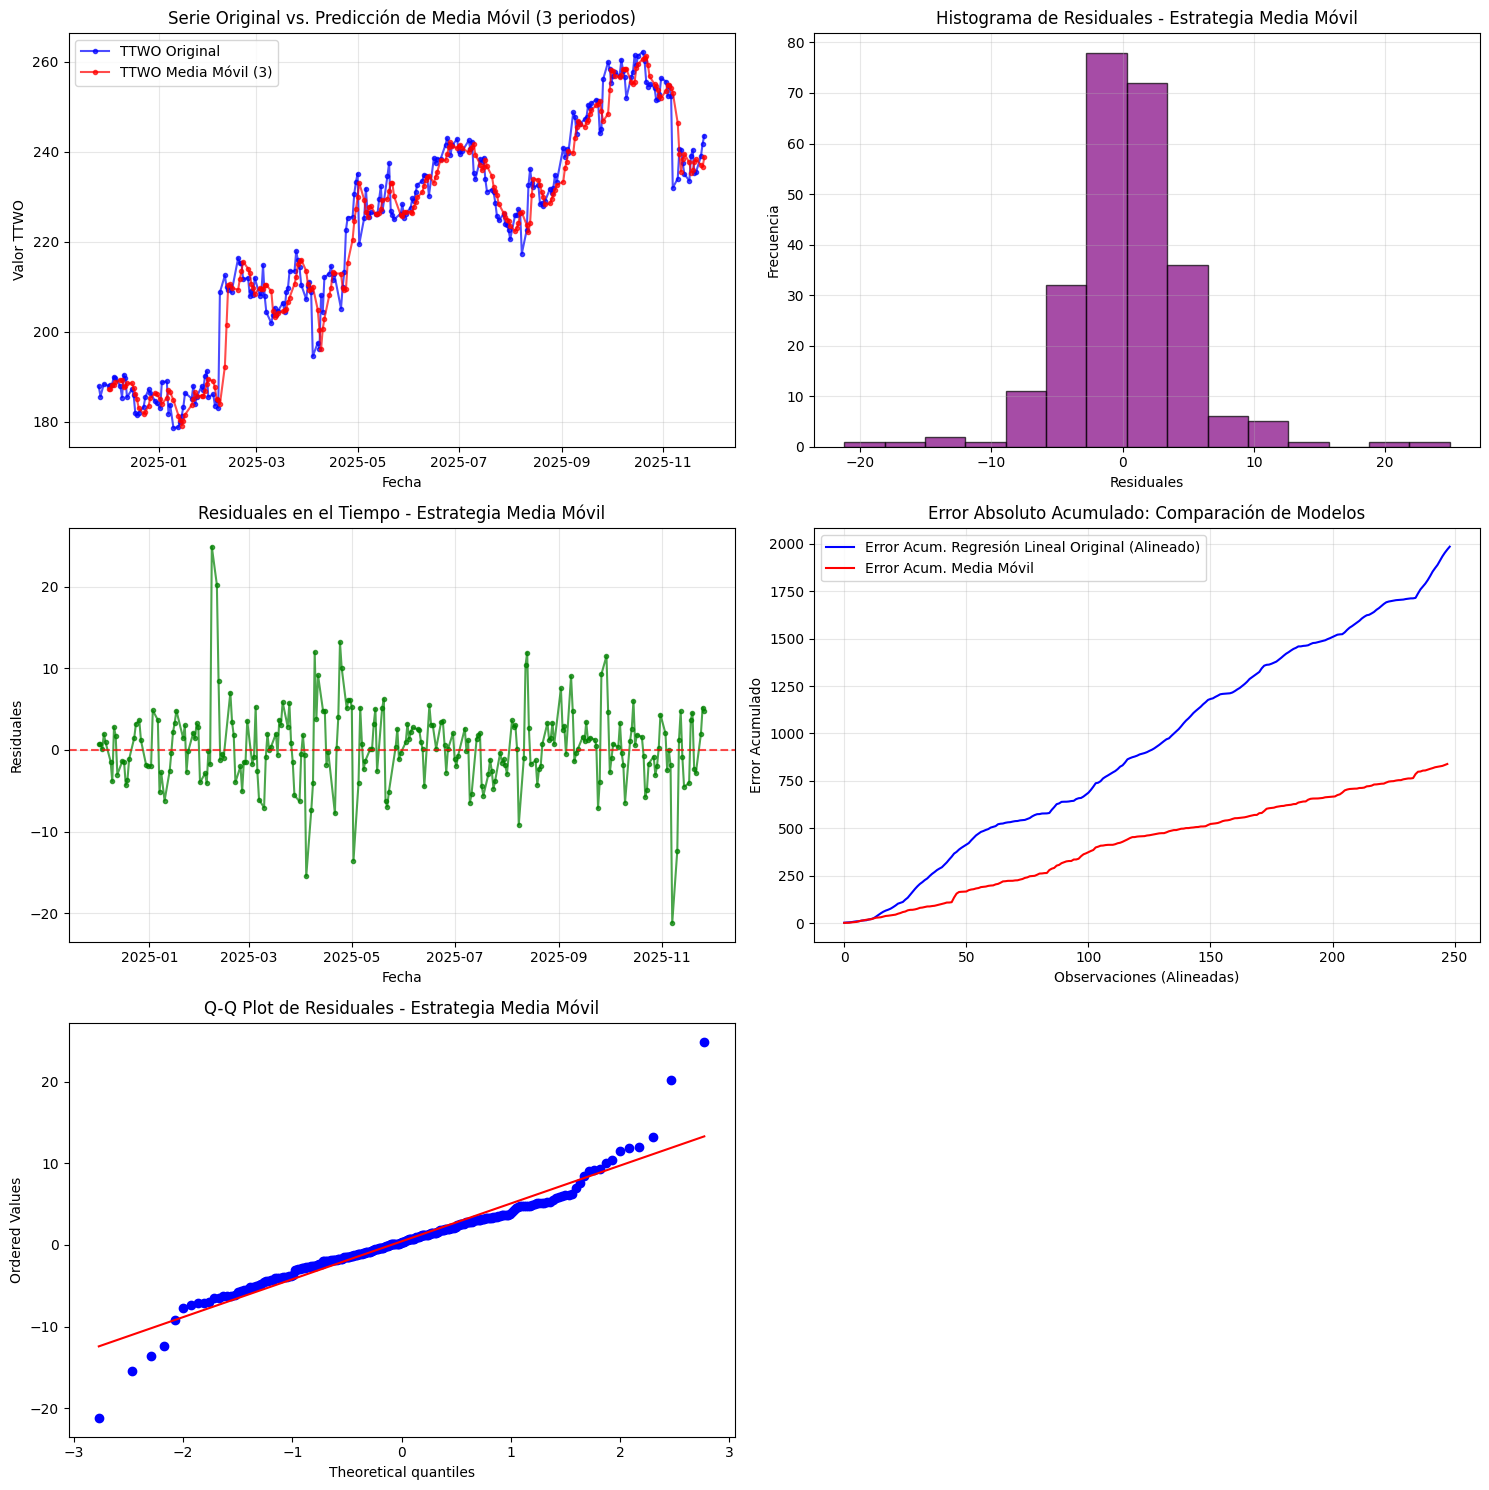

In [26]:
# Gráficas del Modelo de Media Móvil Predictoria
plt.figure(figsize=(15, 15)) # Increased figure size to accommodate 5 plots

# Gráfico 1: Serie original vs Media móvil
plt.subplot(3, 2, 1) # Changed to 3x2 grid
plt.plot(data.index, data['TTWO'], 'bo-', alpha=0.7, label='TTWO Original', markersize=3)
plt.plot(data.index, data['TTWO_MA3'], 'ro-', alpha=0.7, label='TTWO Media Móvil (3)', markersize=3)
plt.title('Serie Original vs. Predicción de Media Móvil (3 periodos)')
plt.xlabel('Fecha')
plt.ylabel('Valor TTWO')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Histograma de Residuales (Media Móvil)
residuals_ma3 = y_original_aligned - y_pred_ma # Recalculate residuals if not already defined for this specific use
plt.subplot(3, 2, 2) # Changed to 3x2 grid
plt.hist(residuals_ma3, bins=15, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('Residuales')
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuales - Estrategia Media Móvil')
plt.grid(True, alpha=0.3)

# Gráfico 3: Residuales en el tiempo (Media Móvil)
# residuals_ma3 is already calculated above
plt.subplot(3, 2, 3) # Changed to 3x2 grid
plt.plot(datos_ma3.index, residuals_ma3, 'go-', alpha=0.7, markersize=3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.title('Residuales en el Tiempo - Estrategia Media Móvil')
plt.xlabel('Fecha')
plt.ylabel('Residuales')
plt.grid(True, alpha=0.3)

# Gráfico 4: Comparación de ajustes (Errores Acumulados)
plt.subplot(3, 2, 4) # Changed to 3x2 grid

# 'residuos' is from the first linear regression (cell mLtdRN8E82mV), its length is 251.
# 'residuals_ma3' has length 249 (since the first two values of EC_MA3 are NaN).
# To compare, we should slice the original residuals to align with the MA3 data.
# datos_ma3 starts at data.index[2], so we should slice 'residuos' from index 2.
residuals_original_aligned = residuos[2:]

# Calculate cumulative absolute errors
error_acum_original = np.cumsum(np.abs(residuals_original_aligned))
error_acum_ma3 = np.cumsum(np.abs(residuals_ma3))

# Both arrays should now have the same length (249)
plt.plot(range(len(error_acum_original)), error_acum_original, 'b-', label='Error Acum. Regresión Lineal Original (Alineado)')
plt.plot(range(len(error_acum_ma3)), error_acum_ma3, 'r-', label='Error Acum. Media Móvil')
plt.title('Error Absoluto Acumulado: Comparación de Modelos')
plt.xlabel('Observaciones (Alineadas)')
plt.ylabel('Error Acumulado')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 5: Q-Q plot de Residuales (Media Móvil)
plt.subplot(3, 2, 5) # New subplot for Q-Q plot
stats.probplot(residuals_ma3, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuales - Estrategia Media Móvil')

plt.tight_layout()
plt.show()

In [27]:
alpha = 0.1 # Coeficiente de suavizamiento (puedes ajustar este valor)
initial_k_points = 8 # Puedes ajustar esto para 'mean_k_points' strategy

# Eliminar columnas existentes si existen para asegurar un reinicio limpio
for col in ['TTWO_Suavizado', 'TTWO_Pronostico', 'Error_Pronostico']:
    if col in data.columns:
        data = data.drop(columns=[col])

# Aplicar la función flexible de Suavizamiento Exponencial Simple
ses_forecast_series, ses_metrics = simple_exponential_smoothing_flexible(
    series=data['TTWO'],
    alpha_val=alpha,
    initial_level_strategy='first_value', # O 'mean_k_points'
    initial_k_points=initial_k_points
)

# Añadir el pronóstico al DataFrame
data['TTWO_Pronostico'] = ses_forecast_series

# Calcular los errores para el pronóstico
data['Error_Pronostico'] = data['TTWO'] - data['TTWO_Pronostico']

# Mostrar resultados
print("="*50)
print("MODELO DE SUAVIZAMIENTO EXPONENCIAL SIMPLE (Clásico)")
print("="*50)
print(f"Coeficiente Alpha: {alpha:.2f}")
print(f"Estrategia de Inicialización: {'mean_k_points' if initial_k_points > 1 else 'first_value'}")
print(f"Puntos Iniciales para S0: {initial_k_points}")
for metric, value in ses_metrics.items():
    print(f"{metric}: {value:.4f}")
print(f"Número de observaciones para métricas: {len(ses_metrics['ME']) if isinstance(ses_metrics['ME'], np.ndarray) else (len(data['EC']) - 1) }") # Adjust for correct count after dropping first forecast

display(data.head())

NameError: name 'simple_exponential_smoothing_flexible' is not defined